Takes your loaded dataset and produces a new one with suboptimal labels, optionally dependent on the input

In [38]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt

# ==== Load ====
filepath = '/home/khain/FSNet/datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000'
with open(filepath, 'rb') as f:
    dataset = pickle.load(f)

print(dataset.keys())

X = dataset['X']   # shape (N, n)
Y = dataset['Y']   # shape (N, n)

dict_keys(['Q', 'p', 'A', 'X', 'G', 'h', 'C', 'd', 'YL', 'YU', 'XL', 'XU', 'Y', 'best_partial'])


In [39]:
# ==== Config ====
subopt_noise = 1.0    # random solver variation
bias_strength = 1.0   # systematic bias magnitude
input_dependence = True
savepath = filepath + '_subopt_noise{}_bias{}'.format(subopt_noise, bias_strength)

# ==== Synthetic suboptimal data ====
rng = np.random.default_rng(42)

# 1) Base random noise
noise = rng.standard_normal(Y.shape) * subopt_noise

# 2) Scale noise by input magnitude (optional)
if input_dependence:
    noise *= 1.0 + np.mean(np.abs(X), axis=1, keepdims=True)

# 3) Add small mean shift (asymmetry / bias)
noise += 0.1 * subopt_noise

# 4) Add input-correlated directional bias
bias_dir = rng.standard_normal(Y.shape[1])
bias_dir /= np.linalg.norm(bias_dir) + 1e-8
bias = bias_strength * bias_dir * np.sign(np.mean(X, axis=1, keepdims=True))

# 5) Combine
Y_subopt = Y - noise - bias

# sample from some curvy f(x)

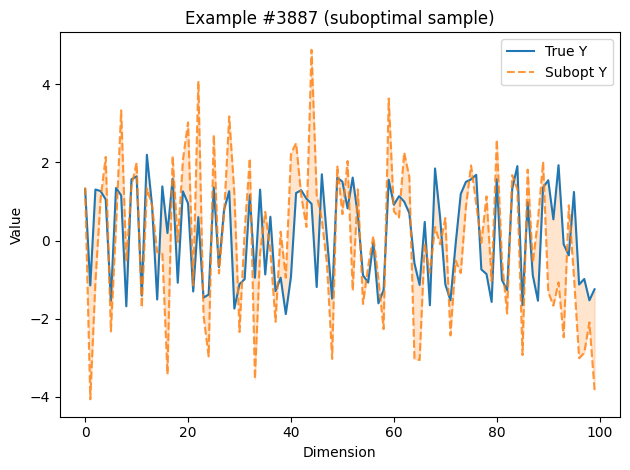

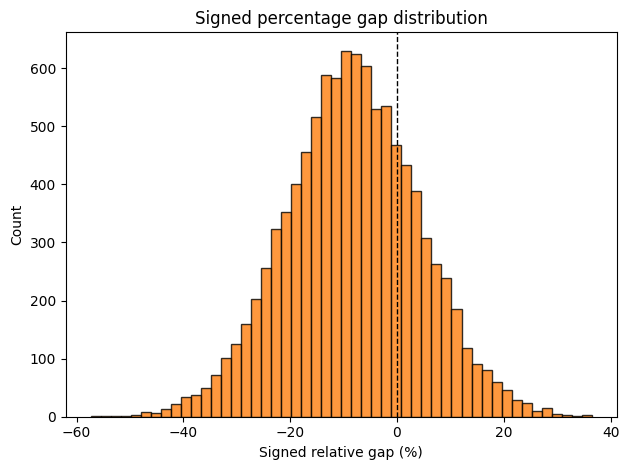

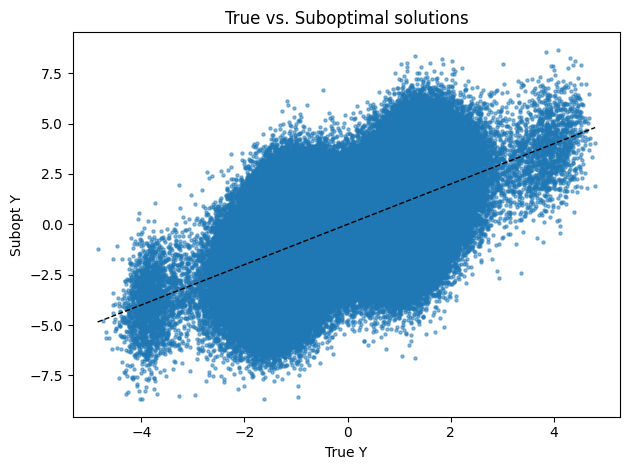

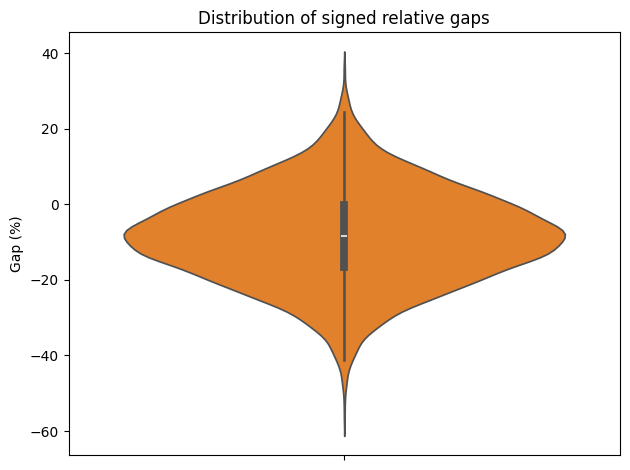

In [40]:
# showing local deviation patterns.
idx = rng.integers(len(Y))
plt.figure()
plt.plot(Y[idx], label='True Y', color='C0')
plt.plot(Y_subopt[idx], '--', label='Subopt Y', color='C1', alpha=0.8)
plt.fill_between(range(Y.shape[1]), Y[idx], Y_subopt[idx], color='C1', alpha=0.2)
plt.title(f"Example #{idx} (suboptimal sample)")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

# showing overall distribution of differences.
gap = 100 * np.mean(Y_subopt - Y, axis=1) / (np.mean(np.abs(Y), axis=1) + 1e-12)
plt.hist(gap, bins=50, color='C1', alpha=0.8, edgecolor='black')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Signed percentage gap distribution")
plt.xlabel("Signed relative gap (%)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# showing correlation or bias direction.
plt.figure()
plt.scatter(Y.flatten(), Y_subopt.flatten(), s=5, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'k--', lw=1)
plt.xlabel("True Y")
plt.ylabel("Subopt Y")
plt.title("True vs. Suboptimal solutions")
plt.tight_layout()
plt.show()

# showing spread across dataset or noise levels.
import seaborn as sns
sns.violinplot(y=gap, color='C1', inner='box')
plt.title("Distribution of signed relative gaps")
plt.ylabel("Gap (%)")
plt.tight_layout()
plt.show()

In [41]:
# ==== Save new dataset ====
dataset_subopt = dict(dataset)
dataset_subopt['Y_subopt'] = Y_subopt

os.makedirs(os.path.dirname(savepath), exist_ok=True)
with open(savepath, 'wb') as f:
    pickle.dump(dataset_subopt, f)

print(f"✅ Saved synthetic dataset: {savepath}")
print("Y:", Y.shape, "| Y_subopt:", Y_subopt.shape)

✅ Saved synthetic dataset: /home/khain/FSNet/datasets/nonsmooth_nonconvex/socp/random2025_socp_dataset_var100_ineq50_eq50_ex10000_subopt_noise1.0_bias1.0
Y: (10000, 100) | Y_subopt: (10000, 100)
